## 1. Load Classification Dataset

In [133]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [134]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/ML/classification_data.csv')

In [135]:
data.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,2.068058,3.109704,3,-0.435250,1,4.635022,-0.683808,0.335669,0,1.286950,0
1,2.068058,0.684123,0,-0.435250,2,4.635022,0.625464,2.516940,0,2.031396,0
2,2.068058,1.765147,0,1.103605,5,3.736191,-1.011126,0.771923,0,1.783247,0
3,2.068058,2.265955,0,1.103605,0,2.837361,0.298146,0.117542,0,1.286950,0
4,2.068058,1.791405,0,-0.435250,2,2.837361,1.934737,0.662860,0,2.775843,0


In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58615 entries, 0 to 58614
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58615 non-null  float64
 1   income                   58615 non-null  float64
 2   home_ownership           58615 non-null  int64  
 3   emplyment_length         58615 non-null  float64
 4   loan_intent              58615 non-null  int64  
 5   loan_amount              58615 non-null  float64
 6   loan_interest_rate       58615 non-null  float64
 7   loan_income_ratio        58615 non-null  float64
 8   payment_default_on_file  58615 non-null  int64  
 9   credit_history_length    58615 non-null  float64
 10  loan_approval_status     58615 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.9 MB


## 2. Declare Features and Target

In [137]:
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
                'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
                'payment_default_on_file', 'credit_history_length']

X = data[feature_cols]
y = data['loan_approval_status']

## 3. Train-Test Split

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## 4. Build Base Learners


In [139]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [140]:
y_pred_lr = logreg.predict(X_test)

In [141]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [142]:
y_pred_knn = knn.predict(X_test)

### 4.1 Base Learner Evaluation — LR

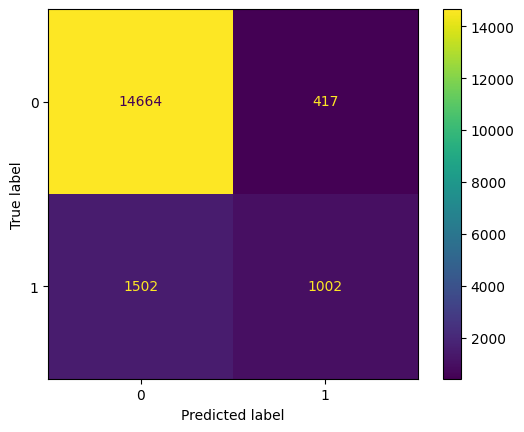

In [143]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=logreg.classes_)
disp.plot()

In [144]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     15081
           1       0.71      0.40      0.51      2504

    accuracy                           0.89     17585
   macro avg       0.81      0.69      0.72     17585
weighted avg       0.88      0.89      0.88     17585



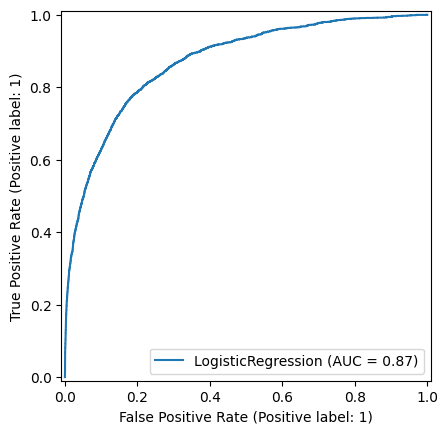

In [145]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(logreg, X_test, y_test)

### 4.2 Base Learner Evaluation — KNN

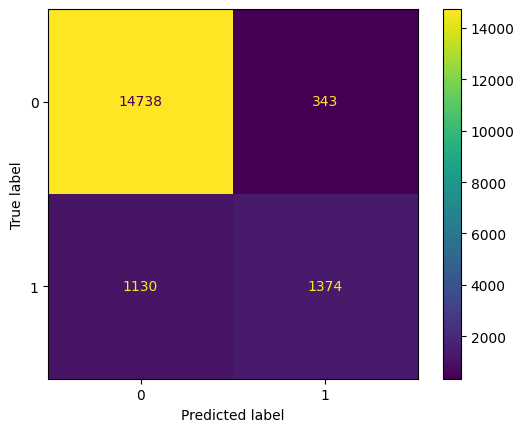

In [146]:
cm = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=knn.classes_)
disp.plot()

In [147]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     15081
           1       0.80      0.55      0.65      2504

    accuracy                           0.92     17585
   macro avg       0.86      0.76      0.80     17585
weighted avg       0.91      0.92      0.91     17585



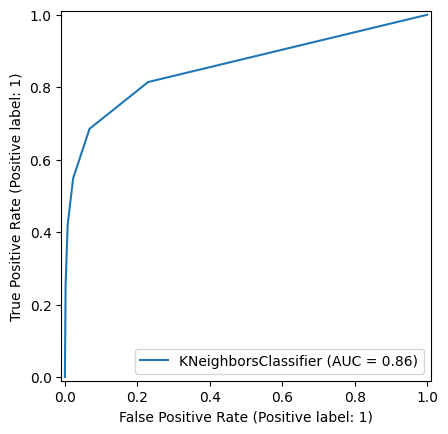

In [148]:
RocCurveDisplay.from_estimator(knn, X_test, y_test)

## 5. Voting Ensemble Classifier

In [149]:
from sklearn.ensemble import VotingClassifier

base_learners = [('logreg', logreg), ('knn', knn)]
ensemble_learner = VotingClassifier(base_learners, voting='soft')

In [150]:
ensemble_learner.fit(X_train, y_train)

VotingClassifier(estimators=[('logreg', LogisticRegression(max_iter=500)),
                             ('knn', KNeighborsClassifier())],
                 voting='soft')

In [151]:
y_pred_ensemble_learner = ensemble_learner.predict(X_test)

### 5.1 Ensemble Evaluation

In [152]:
from sklearn.metrics import accuracy_score

ensemble_learner_accuracy = accuracy_score(y_test, y_pred_ensemble_learner)
ensemble_learner_accuracy

0.9129371623542792

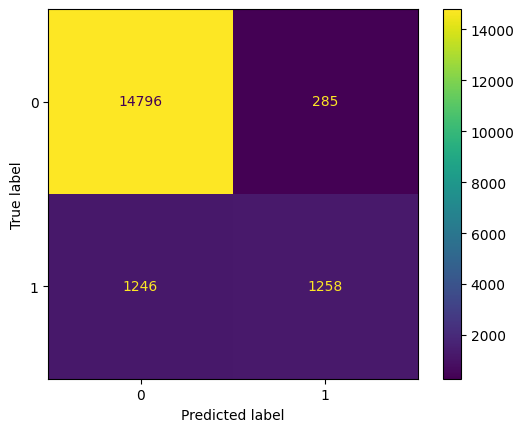

In [153]:
ensemble_learner_cm_test = confusion_matrix(y_test, y_pred_ensemble_learner, labels=ensemble_learner.classes_)
ensemble_learner_disp = ConfusionMatrixDisplay(ensemble_learner_cm_test, display_labels=ensemble_learner.classes_)
ensemble_learner_disp.plot()

In [154]:
print(classification_report(y_test, y_pred_ensemble_learner))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     15081
           1       0.82      0.50      0.62      2504

    accuracy                           0.91     17585
   macro avg       0.87      0.74      0.79     17585
weighted avg       0.91      0.91      0.90     17585



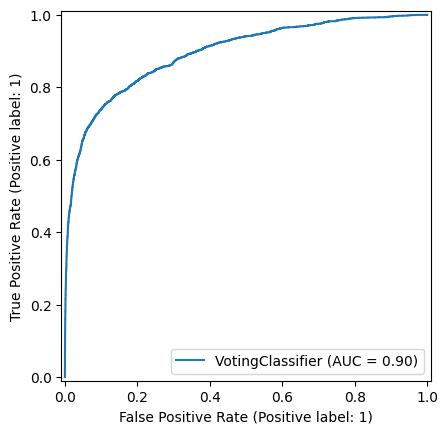

In [155]:
RocCurveDisplay.from_estimator(ensemble_learner, X_test, y_test)

## 6. Load Regression Dataset

In [156]:
reg_data = pd.read_csv('/content/drive/MyDrive/ML/regression_data.csv')

In [157]:
reg_data.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
0,2.068058,3.109704,3,-0.435250,1,4.635022,-0.683808,0.335669,0,1.286950,35000
1,2.068058,0.684123,0,-0.435250,2,4.635022,0.625464,2.516940,0,2.031396,35000
2,2.068058,1.765147,0,1.103605,5,3.736191,-1.011126,0.771923,0,1.783247,30000
3,2.068058,2.265955,0,1.103605,0,2.837361,0.298146,0.117542,0,1.286950,25000
4,2.068058,1.791405,0,-0.435250,2,2.837361,1.934737,0.662860,0,2.775843,25000


In [158]:
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50270 entries, 0 to 50269
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      50270 non-null  float64
 1   income                   50270 non-null  float64
 2   home_ownership           50270 non-null  int64  
 3   emplyment_length         50270 non-null  float64
 4   loan_intent              50270 non-null  int64  
 5   loan_amount              50270 non-null  float64
 6   loan_interest_rate       50270 non-null  float64
 7   loan_income_ratio        50270 non-null  float64
 8   payment_default_on_file  50270 non-null  int64  
 9   credit_history_length    50270 non-null  float64
 10  max_allowed_loan         50270 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.2 MB


## 7. Declare Features and Target

In [159]:
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
                'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
                'payment_default_on_file', 'credit_history_length']

X = reg_data[feature_cols]
y = reg_data['max_allowed_loan']

## 8. Train-Test Split

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

DT-1: Fully Grown Decision Tree Regressor

In [161]:
from sklearn.tree import DecisionTreeRegressor

dt1 = DecisionTreeRegressor(random_state=42)
dt1.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [162]:
y_pred_dt1 = dt1.predict(X_test)

In [163]:
dt1.get_depth()

24

In [164]:
dt1.get_n_leaves()

np.int64(20684)

DT-2: Pruned Decision Tree Regressor



In [165]:
dt2 = DecisionTreeRegressor(max_depth=4, min_samples_leaf=50, random_state=42)
dt2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=50, random_state=42)

In [166]:
y_pred_dt2 = dt2.predict(X_test)

In [167]:
dt2.get_depth()

4

In [168]:
dt2.get_n_leaves()

np.int64(13)

## 11. Visualise Decision Trees

In [169]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

### DT-1 Fully Grown (first 5 levels shown)

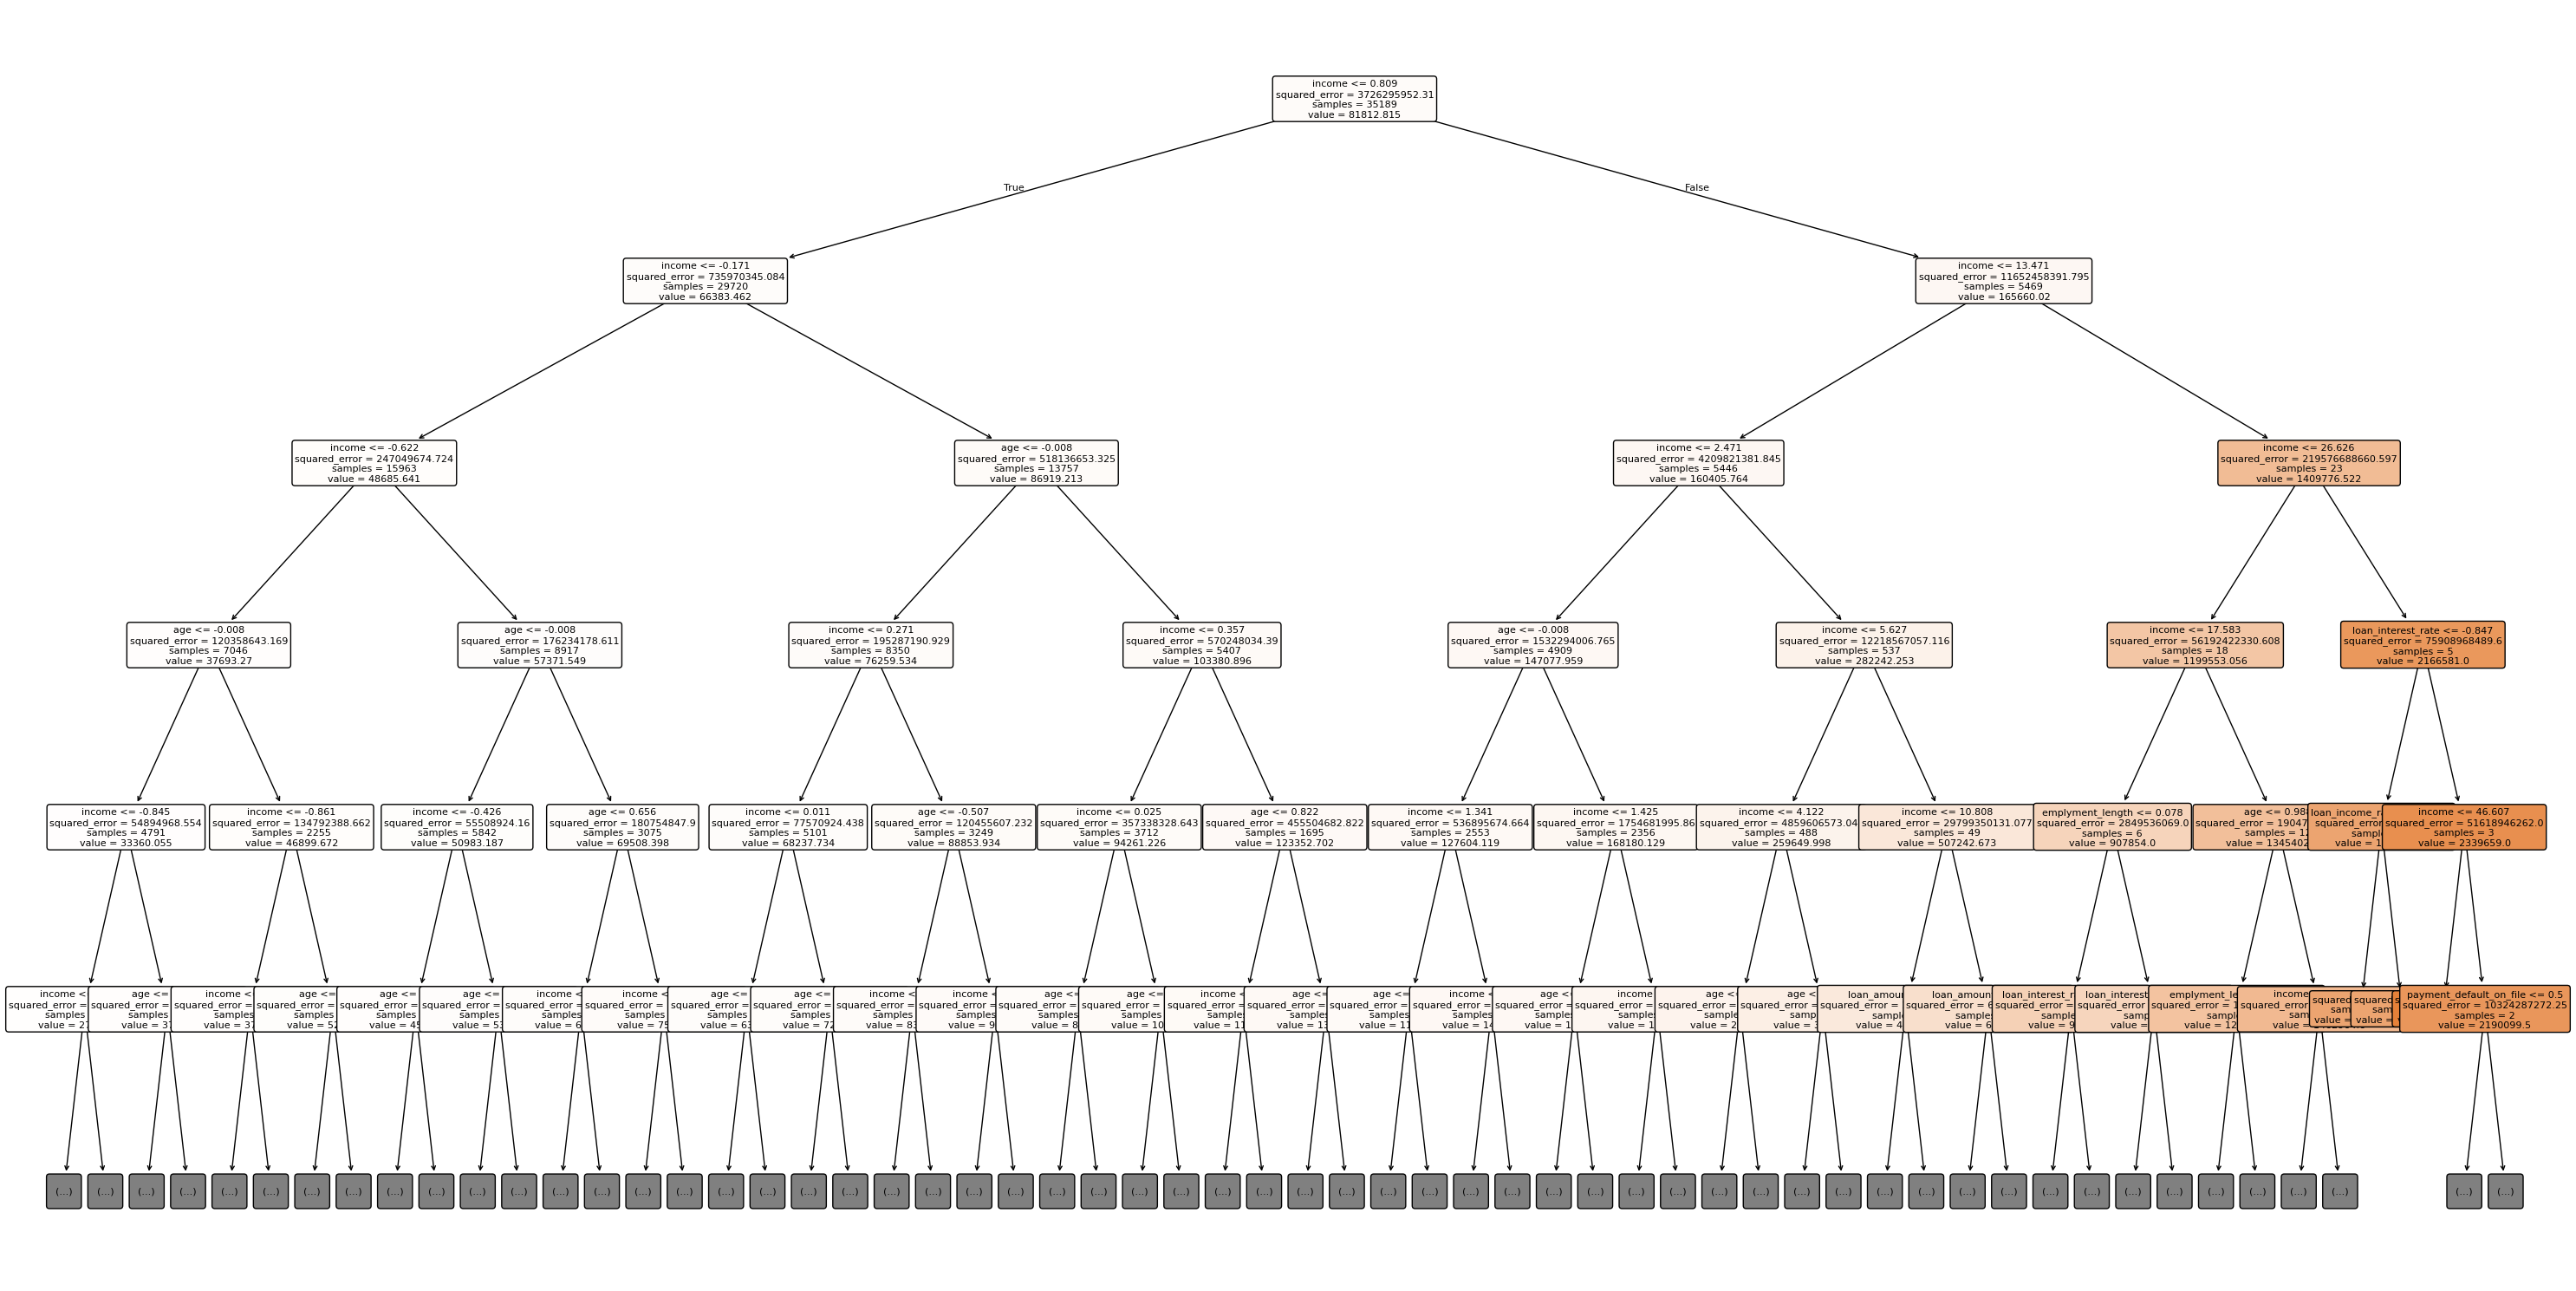

In [170]:
fig, ax = plt.subplots(figsize=(30, 15))
plot_tree(dt1, feature_names=feature_cols, filled=True, rounded=True, ax=ax, max_depth=5, fontsize=8)
plt.tight_layout()
plt.show()

### DT-2 Pruned (all 4 levels)

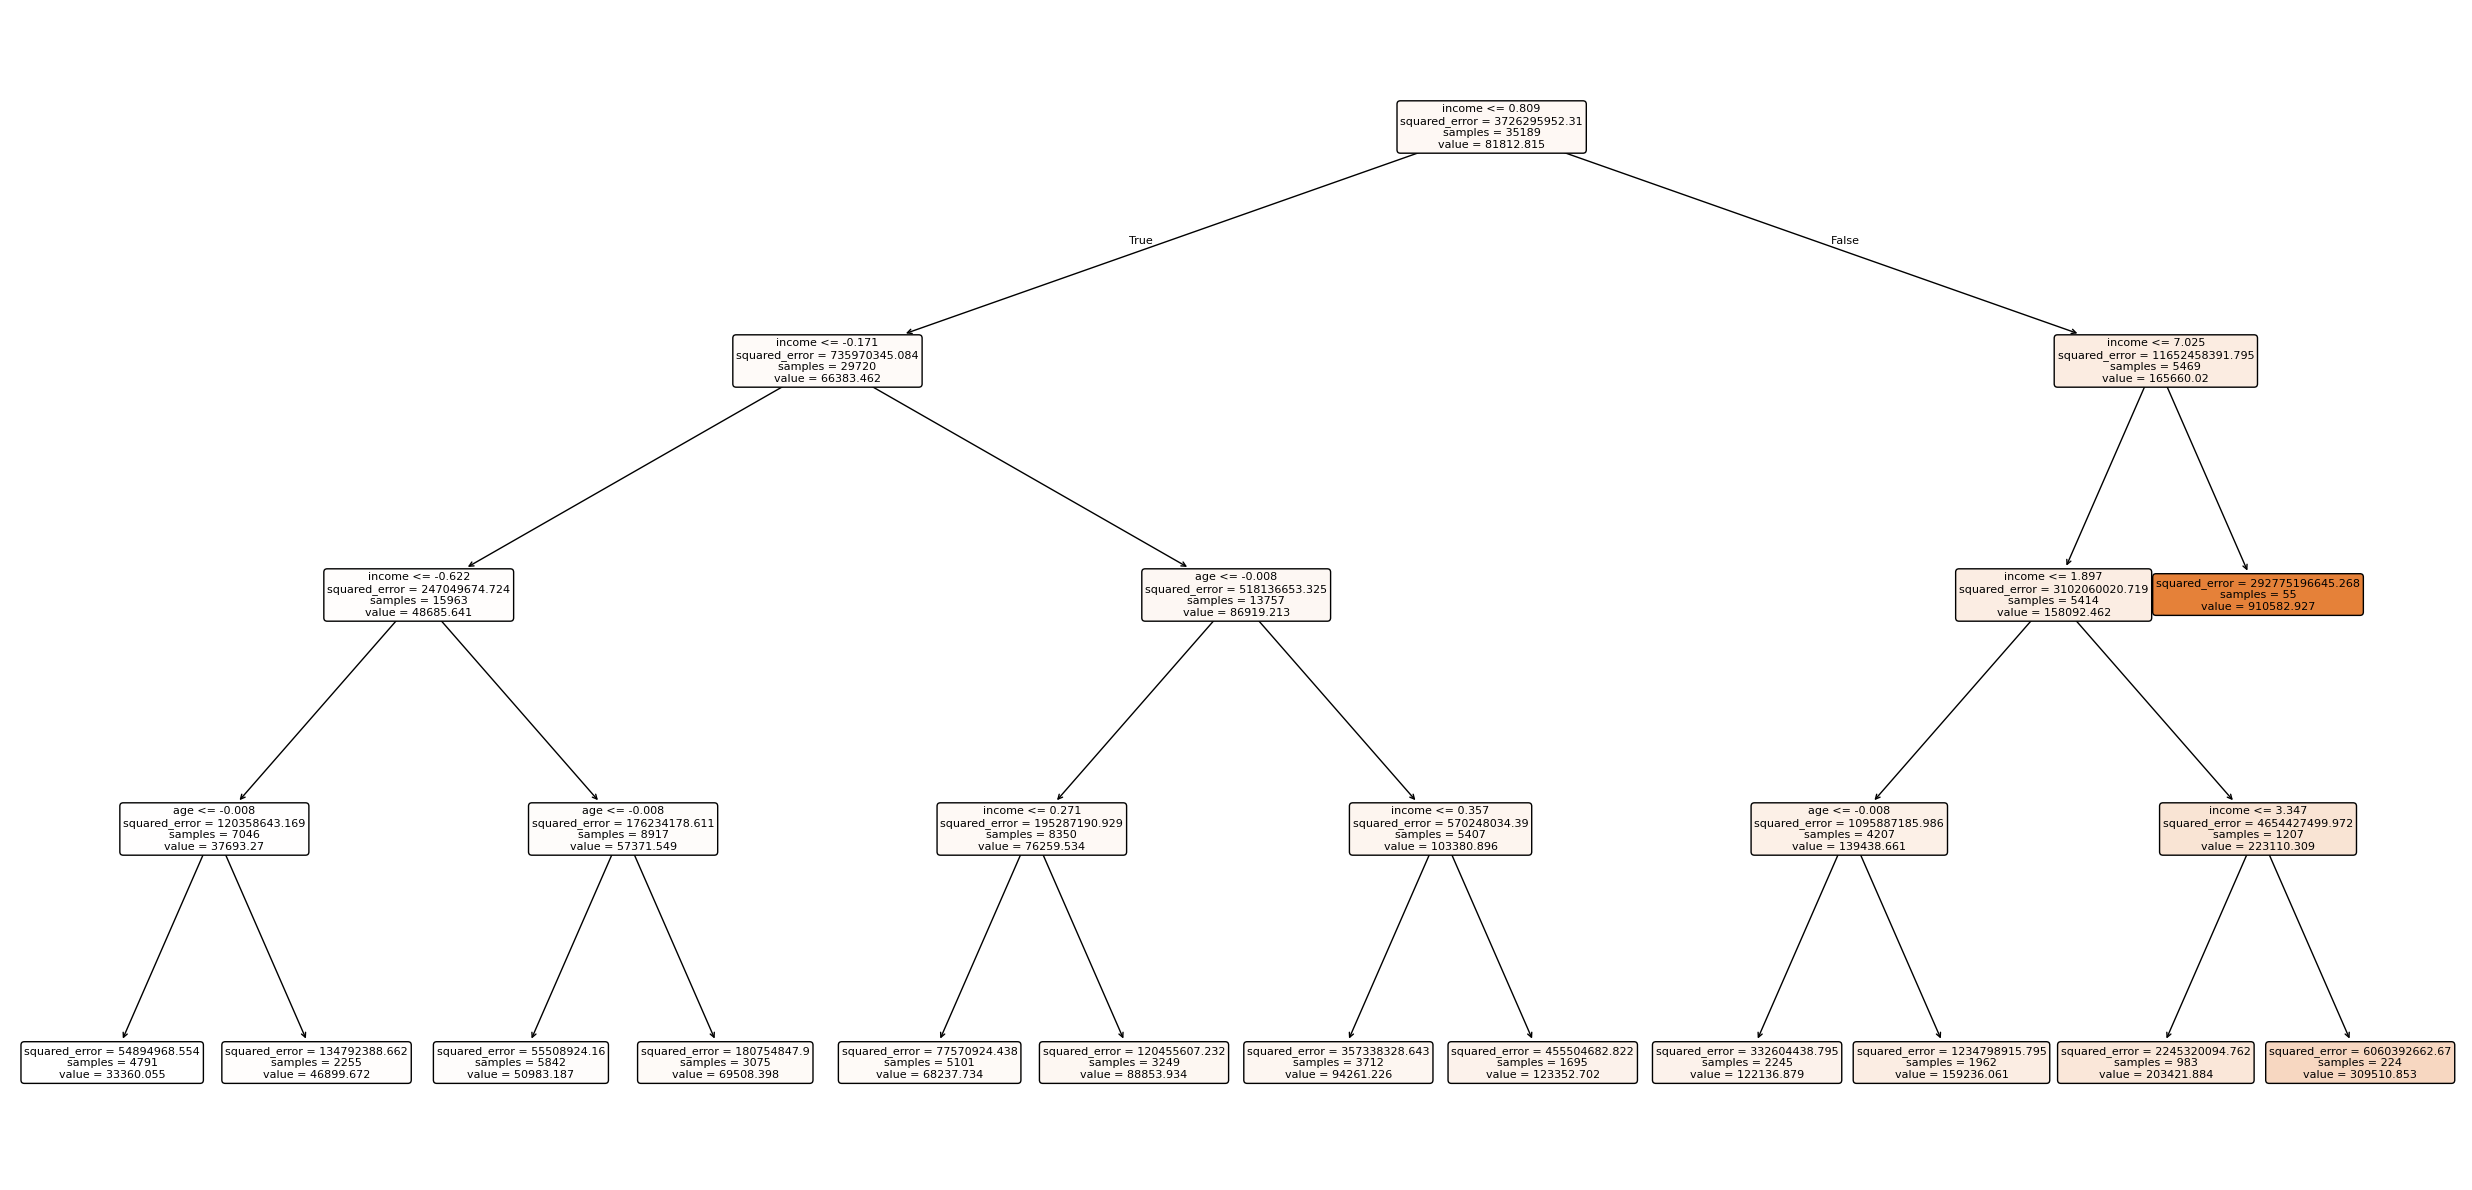

In [171]:
fig, ax = plt.subplots(figsize=(25, 12))
plot_tree(dt2, feature_names=feature_cols, filled=True, rounded=True, ax=ax, fontsize=8)
plt.tight_layout()
plt.show()

## 12. Evaluate Regression Models

In [172]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### DT-1 Metrics

In [173]:
mean_squared_error(y_test, y_pred_dt1)

63101566.91870566

In [174]:
mean_absolute_error(y_test, y_pred_dt1)

1252.8111531065579

In [175]:
r2_score(y_test, y_pred_dt1)

0.9754031108671517

### DT-2 Metrics

In [176]:
mean_squared_error(y_test, y_pred_dt2)

392020378.330652

In [177]:
mean_absolute_error(y_test, y_pred_dt2)

11081.553794144129

In [178]:
r2_score(y_test, y_pred_dt2)

0.8471910880432054

## 13. Predict Maximum Loan Amount for Client 60256



In [179]:
import numpy as np

client_60256_raw = {
    'age': 56, 'income': 57000, 'home_ownership': 3, 'emplyment_length': 15,
    'loan_intent': 3, 'loan_amount': 25700, 'loan_interest_rate': 23,
    'loan_income_ratio': 0.10, 'payment_default_on_file': 0, 'credit_history_length': 35
}

scaler_means = {'age': 27.5494, 'income': 64050.7573, 'emplyment_length': 4.6970,
                'loan_amount': 9216.3738, 'loan_interest_rate': 10.0891,
                'loan_income_ratio': 0.1592, 'credit_history_length': 5.8138}
scaler_stds = {'age': 6.0204, 'income': 37930.6943, 'emplyment_length': 3.8990,
               'loan_amount': 5562.7843, 'loan_interest_rate': 3.0551,
               'loan_income_ratio': 0.0917, 'credit_history_length': 4.0298}

numeric_cols = ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']

client_scaled = {}
for col in feature_cols:
    if col in numeric_cols:
        client_scaled[col] = (client_60256_raw[col] - scaler_means[col]) / scaler_stds[col]
    else:
        client_scaled[col] = client_60256_raw[col]

client_df = pd.DataFrame([client_scaled])
client_df

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length
0,4.725699,-0.185885,3,2.642472,3,2.963197,4.226016,-0.645583,0,7.242593


In [180]:
dt2.predict(client_df)

array([69508.39772358])

### Decision Path for Client 60256

In [181]:
node_indicator = dt2.decision_path(client_df)
node_indices = node_indicator.indices

tree = dt2.tree_
for node_id in node_indices:
    if tree.children_left[node_id] != tree.children_right[node_id]:
        feature_name = feature_cols[tree.feature[node_id]]
        threshold = tree.threshold[node_id]
        value = client_df.iloc[0][feature_name]
        direction = "left (<=)" if value <= threshold else "right (>)"
        display("Node " + str(node_id) + ": " + feature_name + " = " + str(round(value, 4)) + " vs threshold " + str(round(threshold, 4)) + " -> " + direction)
    else:
        display("Leaf Node " + str(node_id) + ": Predicted value = " + str(round(tree.value[node_id][0][0], 2)) + " | Samples = " + str(tree.n_node_samples[node_id]))

'Node 0: income = -0.1859 vs threshold 0.809 -> left (<=)'

'Node 1: income = -0.1859 vs threshold -0.1705 -> left (<=)'

'Node 2: income = -0.1859 vs threshold -0.6217 -> right (>)'

'Node 6: age = 4.7257 vs threshold -0.0082 -> right (>)'

'Leaf Node 8: Predicted value = 69508.4 | Samples = 3075'